# Exploración de datos y descripción

Siempre será importante analizar el conjunto de datos, realizar algunos gráficos que puedan dar nociones de los patrones, etc.

## Importación de librerías

In [3]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns

In [4]:
# Por preferencia al mostrar los números, ase ajustarán a 2 decimales

pd.set_option("display.float_format", "{:.2f}".format)

## Cargar los datos

Recordemos que el dataset correcto fue almacenado con el nombre de `02_datos_con_tipo_de_dato_ajustado_titanic.parquet`

In [5]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

In [6]:
DATA_DIR


PosixPath('/mnt/c/Users/david.palacio/Documents/projects/DataAI-Fundamentos-Aplicaciones/Analitica/proyectos/titanic/datos')

In [7]:
datos_titanic = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_titanic.parquet", engine="pyarrow")

In [8]:
datos_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   survived  1309 non-null   bool    
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int8    
 6   parch     1309 non-null   int8    
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: bool(1), category(2), float64(2), int64(1), int8(2), object(1)
memory usage: 47.7+ KB


In [9]:
datos_titanic["pclass"] = pd.Categorical(
    datos_titanic["pclass"], categories=[3, 2, 1], ordered=True
)

In [10]:
datos_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   category
 1   survived  1309 non-null   bool    
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int8    
 6   parch     1309 non-null   int8    
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: bool(1), category(3), float64(2), int8(2), object(1)
memory usage: 38.9+ KB


In [11]:
datos_titanic.shape

(1309, 9)

In [12]:
datos_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked
0,1,True,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,211.34,S
1,1,True,"Allison, Master. Hudson Trevor",male,0.92,1,2,151.55,S
2,1,False,"Allison, Miss. Helen Loraine",female,2.00,1,2,151.55,S
3,1,False,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,151.55,S
4,1,False,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,151.55,S


In [13]:
# Verificamos si hay valores nulos en el DataFrame

datos_titanic.isnull().sum()

pclass        0
survived      0
name          0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64

## Variables Numéricas

Una forma sencilla de tener un resumen de las variables numéricas podrías ser:

In [14]:
datos_titanic.describe()

,age,sibsp,parch,fare
count,1046.00,1309.00,1309.00,1308.00
mean,29.88,0.50,0.39,33.30
std,14.41,1.04,0.87,51.76
min,0.17,0.00,0.00,0.00
25%,21.00,0.00,0.00,7.90
50%,28.00,0.00,0.00,14.45
75%,39.00,1.00,0.00,31.27
max,80.00,8.00,9.00,512.33


## Variables Categóricas

In [15]:
# Descripción de las variables categóricas

datos_titanic.describe(include="category")

,pclass,sex,embarked
count,1309,1309,1307
unique,3,2,3
top,3,male,S
freq,709,843,914


## Análisis Univariado

La variable objetivo es `survived`.

### Variable Objetivo

<Axes: title={'center': 'Pasajeros sobrevivientes'}, xlabel='survived'>

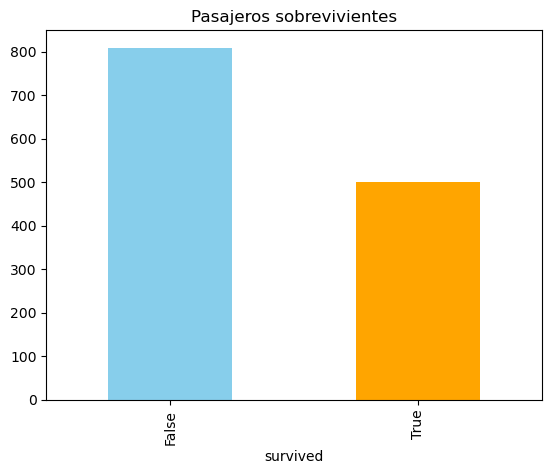

In [16]:
datos_titanic["survived"].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title="Pasajeros sobrevivientes"
)

### Variables Numéricas

In [17]:
columnas_numericas = list(datos_titanic.select_dtypes(include=["number"]).columns)
columnas_numericas

['age', 'sibsp', 'parch', 'fare']

#### Edad

In [18]:
column = "age"

datos_titanic[column].describe()

count   1046.00
mean      29.88
std       14.41
min        0.17
25%       21.00
50%       28.00
75%       39.00
max       80.00
Name: age, dtype: float64

In [19]:
# ¿Cuántos valores únicos de edad hay?

datos_titanic[column].nunique()

98

<Axes: title={'center': 'age histogram'}, ylabel='Frequency'>

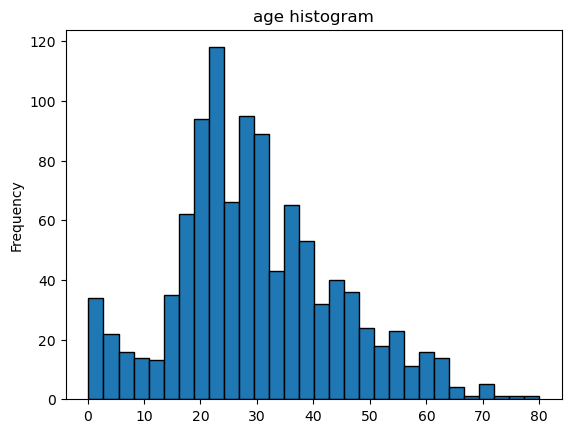

In [20]:
# Histograma con todas las edades

datos_titanic[column].plot(
    kind="hist", bins=30, edgecolor="black", title=f"{column} histogram"
)

<Axes: title={'center': 'age distribution'}, ylabel='Density'>

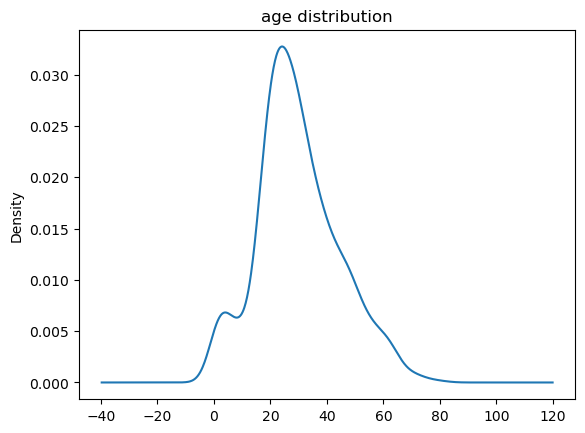

In [21]:
# Gráfico de densidad

datos_titanic[column].plot(
    kind="kde", title=f"{column} distribution"
)

<Axes: title={'center': 'age boxplot'}>

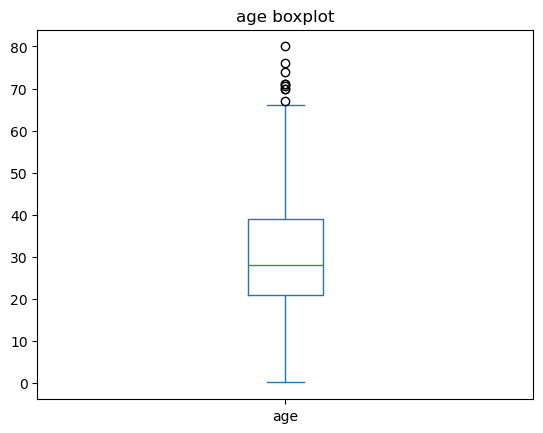

In [22]:
# Diagrama de caja

datos_titanic[column].plot(kind="box", title=f"{column} boxplot")

#### sibsp: hermanos/cónyugues

In [23]:
column = "sibsp"

In [24]:
datos_titanic[column].describe()

count   1309.00
mean       0.50
std        1.04
min        0.00
25%        0.00
50%        0.00
75%        1.00
max        8.00
Name: sibsp, dtype: float64

In [25]:
datos_titanic[column].nunique()

7

In [26]:
# Valores únicos
datos_titanic[column].unique()

array([0, 1, 2, 3, 4, 5, 8], dtype=int8)

<Axes: title={'center': 'sibsp histogram'}, ylabel='Frequency'>

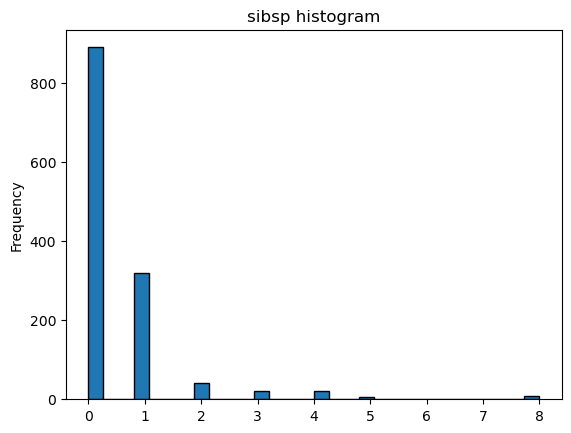

In [27]:
# Histograma con todas las la cantidad de hermanos, hermanas y cónyuges

datos_titanic[column].plot(
    kind="hist", bins=30, edgecolor="black", title=f"{column} histogram"
)

<Axes: title={'center': 'sibsp boxplot'}>

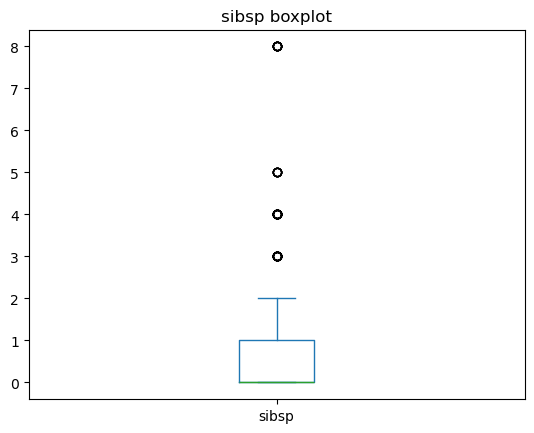

In [28]:
# Diagrama de caja

datos_titanic[column].plot(kind="box", title=f"{column} boxplot")

#### parch: padres/hijos

In [29]:
# parents/children. Número de padres y/o hijos que acompañaba el pasajero en el viaje
column = "parch"

In [30]:
datos_titanic[column].describe()

count   1309.00
mean       0.39
std        0.87
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        9.00
Name: parch, dtype: float64

<Axes: title={'center': 'parch histogram'}, ylabel='Frequency'>

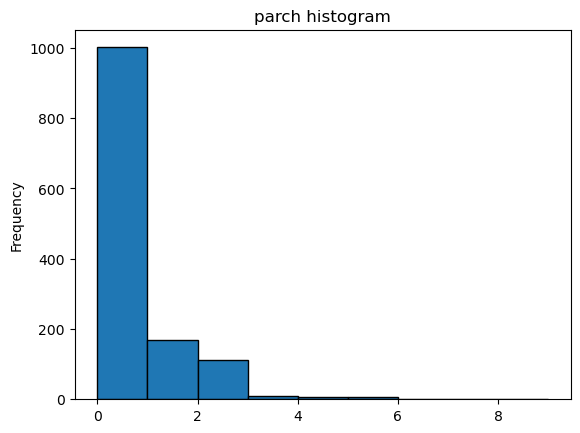

In [31]:
datos_titanic[column].plot(
    kind="hist", bins=9, edgecolor="black", title=f"{column} histogram"
)

#### fare: tarifa en libras esterlinas

In [32]:
# Recordar que esta es la tarifa o precio del boleto

column = "fare"
datos_titanic[column].describe()

count   1308.00
mean      33.30
std       51.76
min        0.00
25%        7.90
50%       14.45
75%       31.27
max      512.33
Name: fare, dtype: float64

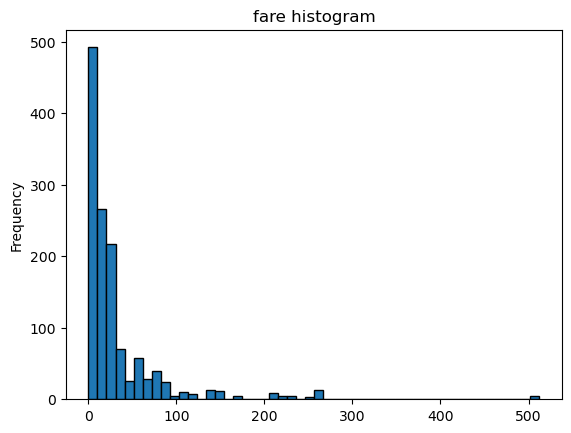

In [33]:
datos_titanic[column].plot(
    kind="hist", bins=50, edgecolor="black", title=f"{column} histogram"
);

<Axes: title={'center': 'fare boxplot'}>

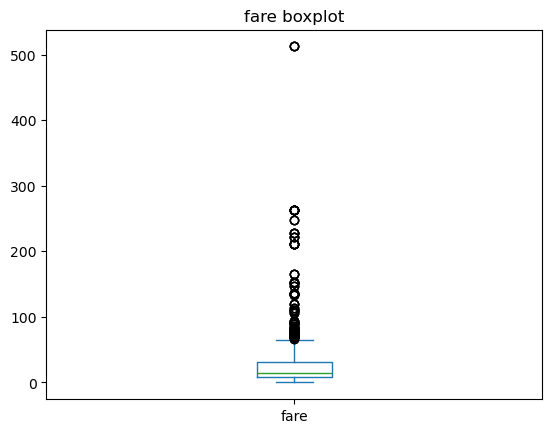

In [34]:
datos_titanic[column].plot(
    kind="box", title=f"{column} boxplot"
)

### Variables Categóricas

In [35]:
variables_categoricas = list(datos_titanic.select_dtypes(include=["category"]).columns)
variables_categoricas

['pclass', 'sex', 'embarked']

#### pclass

In [36]:
column = "pclass"
datos_titanic[column].describe()

count     1309
unique       3
top          3
freq       709
Name: pclass, dtype: int64

In [37]:
datos_titanic[column].unique()

[1, 2, 3]
Categories (3, int64): [3 < 2 < 1]

In [38]:
datos_titanic[column].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

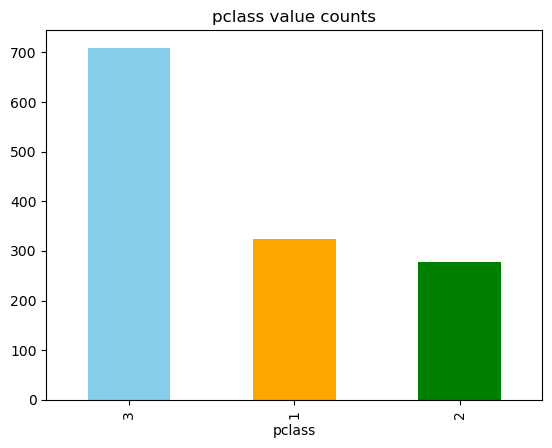

In [39]:
datos_titanic[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### sex

In [40]:
column = "sex"
datos_titanic[column].describe()

count     1309
unique       2
top       male
freq       843
Name: sex, dtype: object

In [41]:
datos_titanic[column].unique()

['female', 'male']
Categories (2, object): ['female', 'male']

In [42]:
datos_titanic[column].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

<Axes: title={'center': 'sex'}, xlabel='sex'>

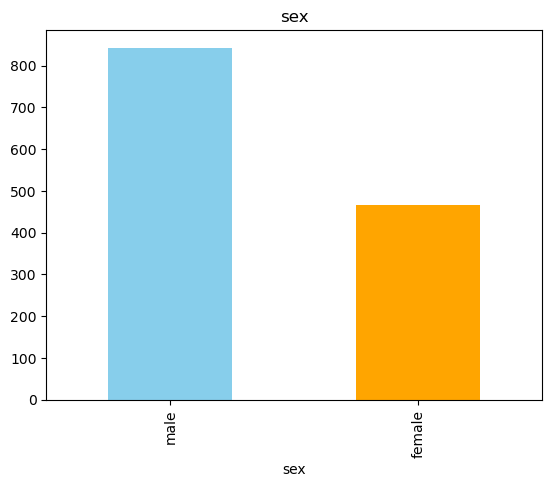

In [43]:
datos_titanic[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column}"
)

#### embarked

Recordar que esta variable hace referencia a los puertos donde embarcaron los pasajeros:
* C: Cherbourg
* Q: Queenstown
* S: Southampton

In [44]:
column = "embarked"
datos_titanic[column].describe()

count     1307
unique       3
top          S
freq       914
Name: embarked, dtype: object

In [45]:
datos_titanic[column].unique()

['S', 'C', NaN, 'Q']
Categories (3, object): ['C', 'Q', 'S']

In [46]:
datos_titanic[column].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

<Axes: title={'center': 'embarked value counts'}, xlabel='embarked'>

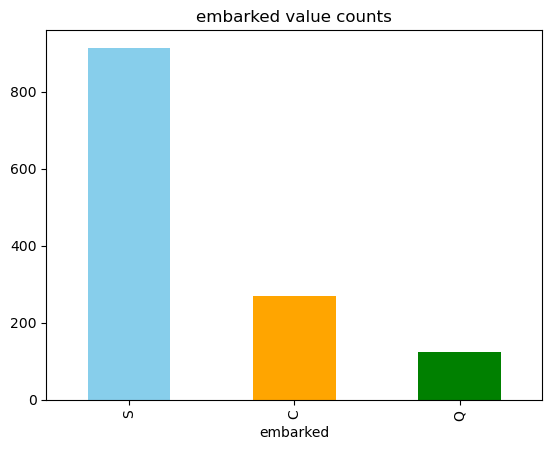

In [47]:
datos_titanic[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
)

### String Columns

In [48]:
datos_titanic["name"].sample(5)

1044                 Murphy, Miss. Nora
1101       Panula, Master. Eino Viljami
172            Julian, Mr. Henry Forbes
257     Schabert, Mrs. Paul (Emma Mock)
231      Peuchen, Major. Arthur Godfrey
Name: name, dtype: object

In [49]:
datos_titanic["name"].nunique()

1307

## Análisis Bivariado

En este punto es importante verificar la relación entre la variable objetivo y las otras variables.

La variable objetivo es `survived`

### Variable objetivo vs Variables numéricas

#### Sobreviviente vs Edad (survived vs age)

age    Axes(0.125,0.11;0.775x0.77)
dtype: object

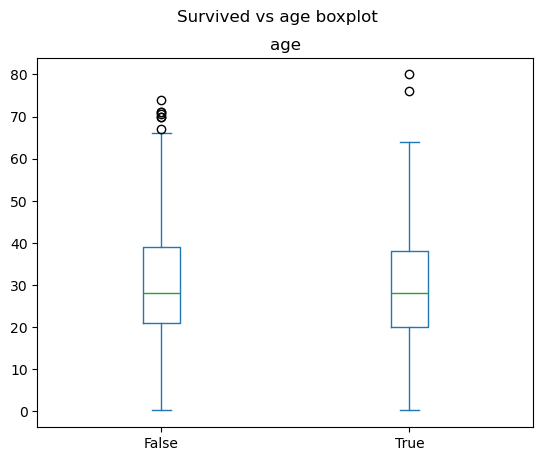

In [50]:
variable = "age"

datos_titanic.plot(
    kind = "box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot"
)

#### Sobreviviente vs hermanos/cónyuges (survived vs sibsp)

sibsp    Axes(0.125,0.11;0.775x0.77)
dtype: object

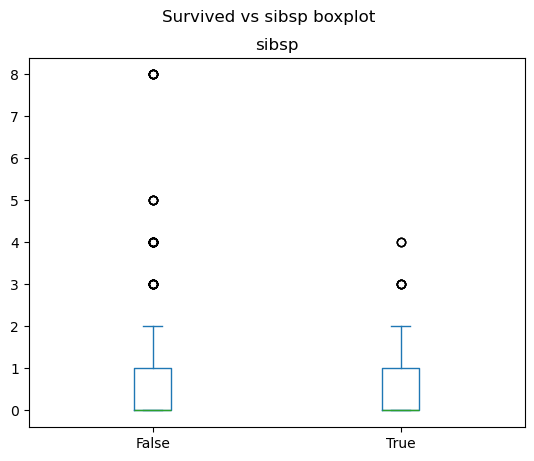

In [51]:
variable = "sibsp"

datos_titanic.plot(
    kind="box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot"
)

<Axes: title={'center': 'survived vs sibsp diagrama de densidad'}, xlabel='sibsp', ylabel='Density'>

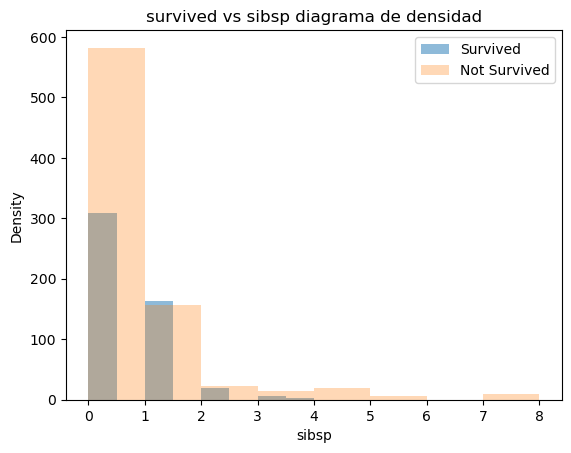

In [53]:
datos_titanic[datos_titanic["survived"] == 1][variable].plot(
    kind="hist",
    label="Survived",
    legend=True,
    bins=8,
    alpha=0.5,
    title=f"survived vs {variable} diagrama de densidad"
)

datos_titanic[datos_titanic["survived"] == 0][variable].plot(
    kind="hist",
    label="Not Survived",
    legend=True,
    bins=8,
    alpha=0.3,
    xlabel=variable,
    ylabel="Density"
)

#### Sobrevivientes vs Padres/Hijos (survived vs parch)

parch    Axes(0.125,0.11;0.775x0.77)
dtype: object

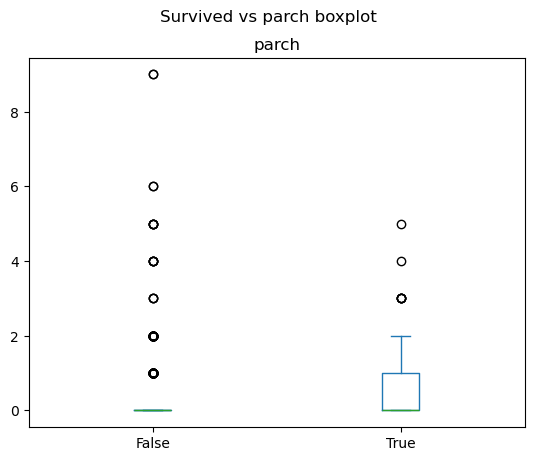

In [54]:
variable = "parch"

datos_titanic.plot(
    kind="box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot"
)

#### Sobrevivientes vs Tarifa (survived vs fare)

fare    Axes(0.125,0.11;0.775x0.77)
dtype: object

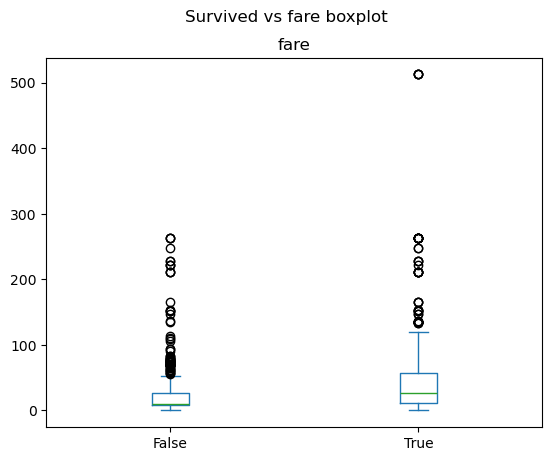

In [55]:
variable = "fare"

datos_titanic.plot(
    kind="box",
    column=variable,
    by="survived",
    grid=False,
    title=f"Survived vs {variable} boxplot",
)

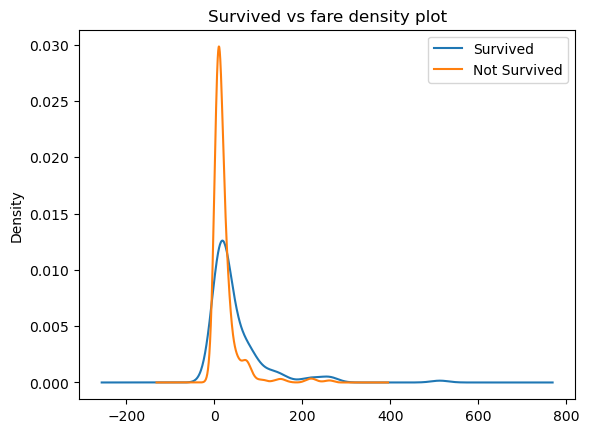

In [56]:
datos_titanic[datos_titanic["survived"] == 1][variable].plot(
    kind="kde",
    label="Survived",
    legend=True,
    title=f"Survived vs {variable} density plot",
)
datos_titanic[datos_titanic["survived"] == 0][variable].plot(
    kind="kde",
    label="Not Survived",
    legend=True,
    xlabel=variable,
    ylabel="Density",
);

### Variables Objetivo vs Variables Categóricas

Una `crosstrab` es una herramienta estadística que se utiliza para resumir y analizar la relación entre dos variables categóricas. En este caso, se usa para crear una tabla que muestra la frecuencia de las combinaciones de valores entre dos columnas de un DataFrame.

#### survived vs pclass

In [59]:
column = "pclass"

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("Survived vs Pclass")
)

survived,False,True,All
pclass,,,
3,528,181,709
2,158,119,277
1,123,200,323
All,809,500,1309


In [ ]:
# Este script permite agrupar los valores únicos del DataFrame y calcular la media de la columna
# survived para cada grupo.

datos_titanic.groupby(column, observed=True).agg({"survived": "mean"}) * 100

,survived
pclass,
3,25.53
2,42.96
1,61.92


En la tabla anterior se puede ver que los pasajeros de segunda clase en promedio sobrevivieron el doble que los pasajeros de tercera clase. A su vez, la mayor cantidad de sobrevivientes es de primera clase.

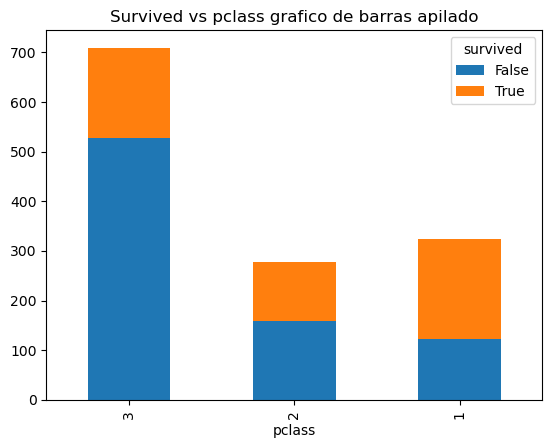

In [62]:
(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar", stacked=True, title=f"Survived vs {column} grafico de barras apilado"
    )
);

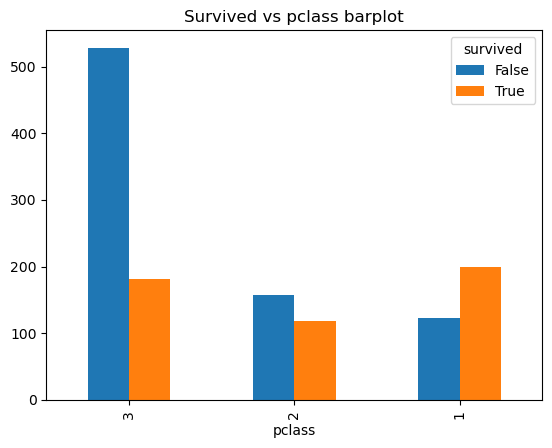

In [63]:
# Gráfico de barras

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar",
        title=f"Survived vs {column} barplot",
    )
);


#### survived vs sex

In [64]:
column = "sex"

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("Survived vs pclass Heatmap")
)

survived,False,True,All
sex,,,
female,127,339,466
male,682,161,843
All,809,500,1309


In [65]:
datos_titanic.groupby(column, observed=True).agg({"survived": "mean"}) * 100

,survived
sex,
female,72.75
male,19.10


<Axes: title={'center': 'Survived vs sex stacked barplot'}, xlabel='sex'>

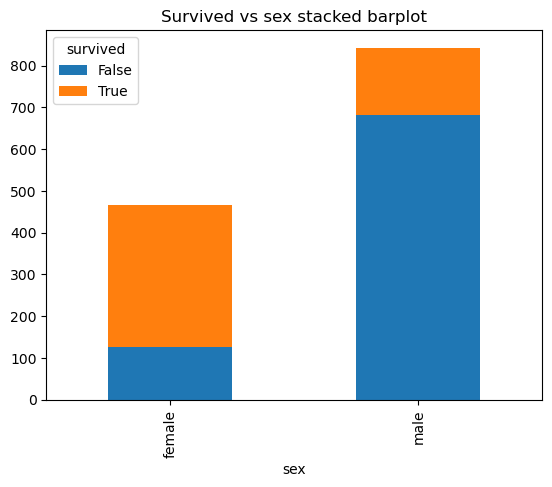

In [67]:
(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar", stacked=True, title=f"Survived vs {column} stacked barplot"
    )
)

#### survived vs embarked

In [68]:
column = "embarked"

(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("Survived vs Embarked Heatmap")
)

survived,False,True,All
embarked,,,
C,120,150,270
Q,79,44,123
S,610,304,914
All,809,498,1307


In [69]:
datos_titanic.groupby(column, observed=True).agg({"survived": "mean"}) * 100

,survived
embarked,
C,55.56
Q,35.77
S,33.26


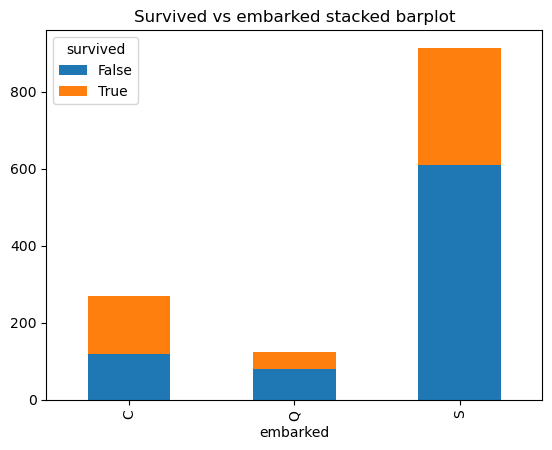

In [70]:
(
    pd.crosstab(datos_titanic[column], datos_titanic["survived"]).plot(
        kind="bar", stacked=True, title=f"Survived vs {column} stacked barplot"
    )
);


### Variables Numéricas vs Numéricas

#### Edad vs sibsp (age vs sibsp)

<Axes: title={'center': 'Diagrama de dispersión de edad vs sibsp'}, xlabel='age', ylabel='sibsp'>

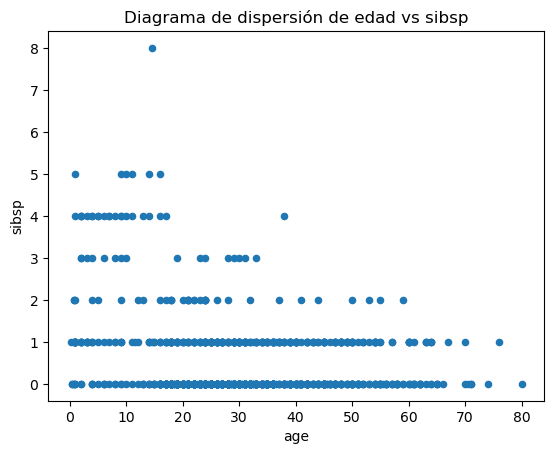

In [71]:
datos_titanic.plot(
    kind="scatter",
    x="age",
    y="sibsp",
    title="Diagrama de dispersión de edad vs sibsp"
)

#### Edad vs Tarifa (age vs fare)

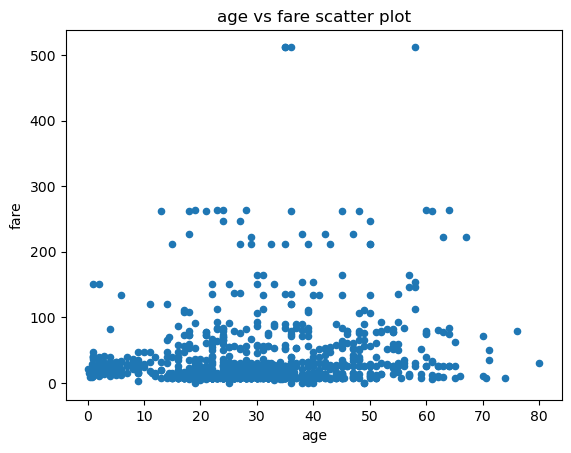

In [72]:
datos_titanic.plot(
    kind="scatter",
    x="age",
    y="fare",
    title="age vs fare scatter plot",
);
